# Sales Dataset Analysis & Data Cleaning
Complete NumPy + Pandas + Matplotlib analysis of the uploaded sales dataset.

**Topics:** exploration, null values, missing-value filling, duplicates, invalid values, business-rule validation, NumPy statistics, Pandas aggregation, Matplotlib visualization, correlation, and cleaned-data export.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv(r"C:\Users\hp\Downloads\ecommerce_customer.csv")

print("Shape:", df.shape)

display(df.head())

Shape: (3055, 32)


,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,Payment_Method,Device,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Return_Status,Order_Status,Marketing_Source,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,Debit Card,Laptop,2,361.67,0.00,6.0,2.9,5.0,No,Delivered,Social Media,1062.0,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,Net Banking,Laptop,2,NaN,28.01,5.0,2.5,3.6,No,Pending,Organic,1252.0,23.2,9,3,5.0,NaN,NaN,NaN,NaN,NaN,NaN
2,ORD100995,C1410,2025-07-13,NaN,Occasional,Hyderabad,West,Electronics,Laptop,Online,Net Banking,Laptop,1,739.05,14.30,7.0,3.9,3.7,No,Pending,Referral,0.0,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,UPI,Laptop,4,7001.11,5.26,4.0,3.5,3.5,No,Returned,Social Media,1388.0,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,Cash,Desktop,2,4920.89,18.72,4.0,5.0,4.6,No,Delivered,Social Media,1132.0,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31


## 1. Dataset Overview

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
display(df.dtypes)
print("\nInformation:")
df.info()


Rows: 3055
Columns: 32

Columns:
['Order_ID', 'Customer_ID', 'Order_Date', 'Customer_Age', 'Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Return_Status', 'Order_Status', 'Marketing_Source', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Net_Sales', 'Estimated_Cost', 'Profit', 'Profit_Margin_Pct']

Data types:


Order_ID                       str
Customer_ID                    str
Order_Date                     str
Customer_Age               float64
Customer_Segment               str
City                           str
Region                         str
Category                       str
Product_Name                   str
Sales_Channel                  str
Payment_Method                 str
Device                         str
Quantity                     int64
Unit_Price                 float64
Discount_Pct               float64
Shipping_Days              float64
Customer_Rating            float64
Delivery_Rating            float64
Return_Status                  str
Order_Status                   str
Marketing_Source               str
Customer_Loyalty_Points    float64
Website_Session_Minutes    float64
Items_Viewed                 int64
Previous_Orders              int64
Customer_Satisfaction      float64
Gross_Amount               float64
Discount_Amount            float64
Net_Sales           


Information:
<class 'pandas.DataFrame'>
RangeIndex: 3055 entries, 0 to 3054
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_ID                 3055 non-null   str    
 1   Customer_ID              3055 non-null   str    
 2   Order_Date               3055 non-null   str    
 3   Customer_Age             2932 non-null   float64
 4   Customer_Segment         3055 non-null   str    
 5   City                     2979 non-null   str    
 6   Region                   3055 non-null   str    
 7   Category                 3055 non-null   str    
 8   Product_Name             3055 non-null   str    
 9   Sales_Channel            3055 non-null   str    
 10  Payment_Method           2978 non-null   str    
 11  Device                   3055 non-null   str    
 12  Quantity                 3055 non-null   int64  
 13  Unit_Price               2962 non-null   float64
 14  Discount_Pct         

In [3]:
display(df.describe())
display(df.describe(include="all"))


,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,2932.000000,3055.000000,2962.00000,2902.000000,2948.000000,2840.000000,3055.000000,2930.000000,2979.000000,3055.000000,3055.000000,2901.000000,2962.000000,2810.000000,2810.000000,2810.000000,2810.000000,2809.000000
mean,35.328104,3.248773,1583.13266,15.407105,4.550543,3.745070,3.673355,872.558362,14.699094,7.062848,5.006219,3.669424,5171.610665,786.158598,4411.498904,3153.257843,1258.241060,28.377437
std,11.316398,1.861875,2366.58516,10.502571,2.288896,0.777563,0.838132,629.154614,9.540359,2.678465,2.276333,0.842385,8994.240302,1681.951220,7595.452348,5346.688134,2529.055858,9.427132
min,-13.000000,-2.000000,12.75000,-10.000000,-3.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,-7620.860000,-780.380000,-6840.480000,-5446.480000,-1394.000000,12.040000
25%,28.000000,2.000000,468.92250,8.250000,3.000000,3.200000,3.100000,363.000000,7.900000,5.000000,3.000000,3.100000,1214.615000,107.150000,1020.622500,723.547500,263.065000,20.280000
50%,35.000000,3.000000,923.14500,14.895000,4.000000,3.800000,3.700000,834.500000,12.700000,7.000000,5.000000,3.700000,2640.185000,327.825000,2286.520000,1613.435000,611.055000,28.230000
75%,42.250000,4.000000,1878.94250,21.670000,6.000000,4.300000,4.300000,1294.000000,19.450000,9.000000,6.000000,4.300000,5730.980000,834.957500,4841.167500,3504.470000,1318.835000,36.400000
max,102.000000,40.000000,61182.50000,120.000000,35.000000,9.000000,5.000000,2970.000000,96.100000,18.000000,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000


,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,Payment_Method,Device,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Return_Status,Order_Status,Marketing_Source,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
count,3055,3055,3055,2932.000000,3055,2979,3055,3055,3055,3055,2978,3055,3055.000000,2962.00000,2902.000000,2948.000000,2840.000000,3055.000000,3055,3055,3055,2930.000000,2979.000000,3055.000000,3055.000000,2901.000000,2962.000000,2810.000000,2810.000000,2810.000000,2810.000000,2809.000000
unique,3000,776,365,NaN,4,20,5,16,10,4,11,4,NaN,NaN,NaN,NaN,NaN,NaN,2,5,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ORD102116,C1744,2025-12-08,NaN,Regular,Chennai,East,Home Appliances,Novel,Online,UPI,Desktop,NaN,NaN,NaN,NaN,NaN,NaN,No,Delivered,Email,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,10,21,NaN,1487,308,629,428,341,873,546,808,NaN,NaN,NaN,NaN,NaN,NaN,2641,2209,640,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,35.328104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.248773,1583.13266,15.407105,4.550543,3.745070,3.673355,NaN,NaN,NaN,872.558362,14.699094,7.062848,5.006219,3.669424,5171.610665,786.158598,4411.498904,3153.257843,1258.241060,28.377437
std,NaN,NaN,NaN,11.316398,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.861875,2366.58516,10.502571,2.288896,0.777563,0.838132,NaN,NaN,NaN,629.154614,9.540359,2.678465,2.276333,0.842385,8994.240302,1681.951220,7595.452348,5346.688134,2529.055858,9.427132
min,NaN,NaN,NaN,-13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.000000,12.75000,-10.000000,-3.000000,0.000000,1.000000,NaN,NaN,NaN,0.000000,1.000000,1.000000,0.000000,1.000000,-7620.860000,-780.380000,-6840.480000,-5446.480000,-1394.000000,12.040000
25%,NaN,NaN,NaN,28.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,468.92250,8.250000,3.000000,3.200000,3.100000,NaN,NaN,NaN,363.000000,7.900000,5.000000,3.000000,3.100000,1214.615000,107.150000,1020.622500,723.547500,263.065000,20.280000
50%,NaN,NaN,NaN,35.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,923.14500,14.895000,4.000000,3.800000,3.700000,NaN,NaN,NaN,834.500000,12.700000,7.000000,5.000000,3.700000,2640.185000,327.825000,2286.520000,1613.435000,611.055000,28.230000
75%,NaN,NaN,NaN,42.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,1878.94250,21.670000,6.000000,4.300000,4.300000,NaN,NaN,NaN,1294.000000,19.450000,9.000000,6.000000,4.300000,5730.980000,834.957500,4841.167500,3504.470000,1318.835000,36.400000


## 2. Missing / Null Values

In [4]:
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_pct
})
display(missing_report[missing_report["Missing_Count"] > 0].sort_values("Missing_Count", ascending=False))


,Missing_Count,Missing_Percentage
Profit_Margin_Pct,246,8.052373
Estimated_Cost,245,8.019640
Discount_Amount,245,8.019640
Net_Sales,245,8.019640
Profit,245,8.019640
Customer_Rating,215,7.037643
Customer_Satisfaction,154,5.040917
Discount_Pct,153,5.008183
Customer_Loyalty_Points,125,4.091653
Customer_Age,123,4.026187


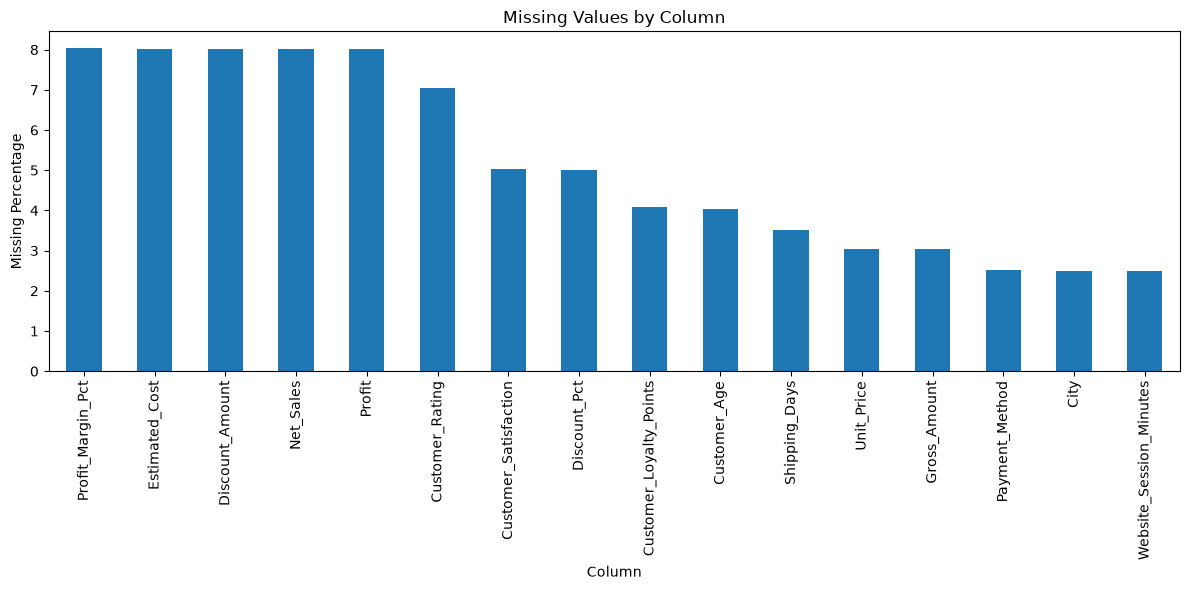

In [5]:
missing_to_plot = missing_pct[missing_pct > 0].sort_values(ascending=False)
plt.figure(figsize=(12,6))
missing_to_plot.plot(kind="bar")
plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Missing Percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 3. Fill Missing Values

In [6]:
df_clean = df.copy()

# Numerical missing values -> median
for column in df_clean.select_dtypes(include=np.number).columns:
    if df_clean[column].isnull().any():
        df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Categorical missing values -> mode
for column in df_clean.select_dtypes(include="object").columns:
    if df_clean[column].isnull().any():
        mode = df_clean[column].mode()
        if len(mode) > 0:
            df_clean[column] = df_clean[column].fillna(mode.iloc[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


C:\Users\hp\AppData\Local\Temp\ipykernel_1204\4287269418.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for column in df_clean.select_dtypes(include="object").columns:


## 4. Duplicate Detection

In [7]:
print("Duplicate rows:", df_clean.duplicated().sum())
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df_clean.shape)


Duplicate rows: 50
Shape after removing duplicates: (3005, 32)


## 5. Invalid-Value Detection
Business rules:
- Quantity: integer from 1 to 10
- Customer Age: 18 to 100
- Discount %: 0 to 100
- Shipping Days: 1 to 14
- Customer Rating: 1 to 5
- Customer Satisfaction: 1 to 5


In [8]:
rules = {
    "Quantity": (1, 10),
    "Customer_Age": (18, 100),
    "Discount_Pct": (0, 100),
    "Shipping_Days": (1, 14),
    "Customer_Rating": (1, 5),
    "Customer_Satisfaction": (1, 5)
}

invalid_report = []
for column, (low, high) in rules.items():
    invalid = ~df_clean[column].between(low, high)
    invalid_report.append([column, int(invalid.sum()), low, high])

invalid_report = pd.DataFrame(
    invalid_report,
    columns=["Column", "Invalid_Count", "Minimum_Allowed", "Maximum_Allowed"]
)
display(invalid_report)


,Column,Invalid_Count,Minimum_Allowed,Maximum_Allowed
0,Quantity,10,1,10
1,Customer_Age,156,18,100
2,Discount_Pct,7,0,100
3,Shipping_Days,6,1,14
4,Customer_Rating,7,1,5
5,Customer_Satisfaction,0,1,5


In [9]:
invalid_quantity = df_clean[~df_clean["Quantity"].between(1, 10)]
print("Invalid Quantity records:")
display(invalid_quantity[["Order_ID", "Quantity"]].head(50))
print("All Quantity values before correction:")
print(sorted(df_clean["Quantity"].unique()))


Invalid Quantity records:


,Order_ID,Quantity
115,ORD101217,0
774,ORD102882,25
801,ORD102532,25
1053,ORD100484,40
1157,ORD101132,-2
1375,ORD100313,25
1673,ORD102321,-2
1896,ORD100853,25
2022,ORD102085,-2
2930,ORD100941,25


All Quantity values before correction:
[np.int64(-2), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(25), np.int64(40)]


## 6. Correct Invalid Values

In [10]:
for column, (low, high) in rules.items():
    valid = df_clean[column].between(low, high)
    df_clean.loc[~valid, column] = np.nan
    valid_median = df_clean.loc[df_clean[column].between(low, high), column].median()
    df_clean[column] = df_clean[column].fillna(valid_median)

for column in ["Quantity", "Customer_Age", "Shipping_Days"]:
    df_clean[column] = df_clean[column].round().astype(int)

print("Invalid values corrected.")


Invalid values corrected.


In [11]:
# Verify the rules after correction
for column, (low, high) in rules.items():
    print(column, "invalid =", int((~df_clean[column].between(low, high)).sum()))

print("\nQuantity values after correction:")
print(sorted(df_clean["Quantity"].unique()))


Quantity invalid = 0
Customer_Age invalid = 0
Discount_Pct invalid = 0
Shipping_Days invalid = 0
Customer_Rating invalid = 0
Customer_Satisfaction invalid = 0

Quantity values after correction:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


## 7. Clean Categorical and Date Columns

In [12]:
for column in ["Payment_Method", "City", "Region", "Category", "Subcategory", "Customer_Segment"]:
    if column in df_clean.columns:
        df_clean[column] = df_clean[column].astype(str).str.strip().str.title()

if "Order_Date" in df_clean.columns:
    df_clean["Order_Date"] = pd.to_datetime(df_clean["Order_Date"], errors="coerce")
    df_clean["Year"] = df_clean["Order_Date"].dt.year
    df_clean["Month"] = df_clean["Order_Date"].dt.month
    df_clean["Month_Name"] = df_clean["Order_Date"].dt.month_name()
    df_clean["Day_Name"] = df_clean["Order_Date"].dt.day_name()

display(df_clean.head())


,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,Payment_Method,Device,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Return_Status,Order_Status,Marketing_Source,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct,Year,Month,Month_Name,Day_Name
0,ORD100994,C1229,2025-06-07,44,Occasional,Delhi,Central,Sports,Shoes,Online,Debit Card,Laptop,2,361.670,0.00,6,2.9,5.0,No,Delivered,Social Media,1062.0,16.4,10,10,1.8,723.340,0.000,723.34,634.670,88.670,12.26,2025,6,June,Saturday
1,ORD101072,C1627,2025-03-18,51,Occasional,Kochi,West,Home Appliances,Shoes,Online,Net Banking,Laptop,2,923.145,28.01,5,2.5,3.6,No,Pending,Organic,1252.0,23.2,9,3,5.0,2640.185,327.825,2286.52,1613.435,611.055,28.23,2025,3,March,Tuesday
2,ORD100995,C1410,2025-07-13,35,Occasional,Hyderabad,West,Electronics,Laptop,Online,Net Banking,Laptop,1,739.050,14.30,7,3.9,3.7,No,Pending,Referral,0.0,9.1,10,6,3.0,739.050,105.680,633.37,370.350,263.020,41.53,2025,7,July,Sunday
3,ORD100731,C1578,2025-09-24,38,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,Upi,Laptop,4,7001.110,5.26,4,3.5,3.5,No,Returned,Social Media,1388.0,22.7,4,4,3.6,28004.440,1473.030,26531.41,17911.620,8619.790,32.49,2025,9,September,Wednesday
4,ORD102954,C1524,2025-06-09,39,Premium,Kolkata,South,Electronics,Skincare,Marketplace,Cash,Desktop,2,4920.890,18.72,4,5.0,4.6,No,Delivered,Social Media,1132.0,6.6,8,8,2.5,9841.780,1842.380,7999.40,6214.630,1784.770,22.31,2025,6,June,Monday


## 8. Validate Calculated Columns

In [13]:
if {"Quantity","Unit_Price","Gross_Amount"}.issubset(df_clean.columns):
    calculated = df_clean["Quantity"] * df_clean["Unit_Price"]
    print("Gross Amount consistent:", np.isclose(df_clean["Gross_Amount"], calculated).all())

if {"Gross_Amount","Discount_Amount","Net_Sales"}.issubset(df_clean.columns):
    calculated = df_clean["Gross_Amount"] - df_clean["Discount_Amount"]
    print("Net Sales consistent:", np.isclose(df_clean["Net_Sales"], calculated).all())

if {"Net_Sales","Estimated_Cost","Profit"}.issubset(df_clean.columns):
    calculated = df_clean["Net_Sales"] - df_clean["Estimated_Cost"]
    print("Profit consistent:", np.isclose(df_clean["Profit"], calculated).all())


Gross Amount consistent: False
Net Sales consistent: False
Profit consistent: False


## 9. NumPy Analysis

In [14]:
numeric_df = df_clean.select_dtypes(include=np.number)
arr = numeric_df.to_numpy()

print("NumPy array shape:", arr.shape)
print("\nMeans:")
display(pd.Series(np.nanmean(arr, axis=0), index=numeric_df.columns))
print("\nMedians:")
display(pd.Series(np.nanmedian(arr, axis=0), index=numeric_df.columns))
print("\nStandard deviations:")
display(pd.Series(np.nanstd(arr, axis=0), index=numeric_df.columns))


NumPy array shape: (3005, 20)

Means:


Customer_Age                 36.361065
Quantity                      3.211647
Unit_Price                 1561.019960
Discount_Pct                 15.232592
Shipping_Days                 4.499834
Customer_Rating               3.748985
Delivery_Rating               3.676339
Customer_Loyalty_Points     868.830782
Website_Session_Minutes      14.667288
Items_Viewed                  7.054576
Previous_Orders               5.005990
Customer_Satisfaction         3.669651
Gross_Amount               5103.371148
Discount_Amount             750.916493
Net_Sales                  4249.992496
Estimated_Cost             3036.734057
Profit                     1208.304296
Profit_Margin_Pct            28.377341
Year                       2025.000000
Month                         6.542429
dtype: float64


Medians:


Customer_Age                 35.000
Quantity                      3.000
Unit_Price                  923.145
Discount_Pct                 14.895
Shipping_Days                 4.000
Customer_Rating               3.800
Delivery_Rating               3.700
Customer_Loyalty_Points     834.500
Website_Session_Minutes      12.700
Items_Viewed                  7.000
Previous_Orders               5.000
Customer_Satisfaction         3.700
Gross_Amount               2640.185
Discount_Amount             327.825
Net_Sales                  2286.520
Estimated_Cost             1613.435
Profit                      611.055
Profit_Margin_Pct            28.230
Year                       2025.000
Month                         7.000
dtype: float64


Standard deviations:


Customer_Age                  9.464941
Quantity                      1.491339
Unit_Price                 2340.731046
Discount_Pct                  9.288077
Shipping_Days                 1.952451
Customer_Rating               0.730147
Delivery_Rating               0.836594
Customer_Loyalty_Points     617.130972
Website_Session_Minutes       9.402874
Items_Viewed                  2.674651
Previous_Orders               2.281073
Customer_Satisfaction         0.820229
Gross_Amount               8920.028617
Discount_Amount            1625.365678
Net_Sales                  7351.140338
Estimated_Cost             5176.054708
Profit                     2446.194069
Profit_Margin_Pct             9.038974
Year                          0.000000
Month                         3.460153
dtype: float64

In [15]:
quantity = df_clean["Quantity"].to_numpy()

print("Mean:", np.mean(quantity))
print("Median:", np.median(quantity))
print("Minimum:", np.min(quantity))
print("Maximum:", np.max(quantity))
print("Standard deviation:", np.std(quantity))
print("25th percentile:", np.percentile(quantity, 25))
print("50th percentile:", np.percentile(quantity, 50))
print("75th percentile:", np.percentile(quantity, 75))


Mean: 3.2116472545757073
Median: 3.0
Minimum: 1
Maximum: 10
Standard deviation: 1.4913385366771421
25th percentile: 2.0
50th percentile: 3.0
75th percentile: 4.0


## 10. Pandas GroupBy Analysis

In [16]:
category_analysis = df_clean.groupby("Category").agg(
    Total_Sales=("Net_Sales","sum"),
    Average_Sales=("Net_Sales","mean"),
    Total_Profit=("Profit","sum"),
    Average_Profit=("Profit","mean"),
    Total_Quantity=("Quantity","sum"),
    Average_Rating=("Customer_Rating","mean")
).sort_values("Total_Sales", ascending=False)

display(category_analysis)


,Total_Sales,Average_Sales,Total_Profit,Average_Profit,Total_Quantity,Average_Rating
Category,,,,,,
Fashion,1826969.40,5117.561345,554334.890,1552.758796,1182,3.706162
Sports,1736003.60,4485.797416,487137.770,1258.753928,1250,3.746512
Grocery,1688405.97,4490.441410,482049.600,1282.046809,1210,3.756915
Home Appliances,1646564.92,3820.336241,470245.955,1091.057900,1346,3.687007
Furniture,1542435.48,4249.133554,431038.735,1187.434532,1180,3.795868
Beauty,1464981.85,4035.762672,391603.495,1078.797507,1172,3.721488
Books,1452505.21,4091.563972,413466.770,1164.695127,1110,3.788169
Electronics,1413361.02,3789.171635,401077.195,1075.273981,1201,3.800000


In [17]:
region_analysis = df_clean.groupby("Region").agg(
    Total_Sales=("Net_Sales","sum"),
    Total_Profit=("Profit","sum"),
    Total_Orders=("Order_ID","count")
).sort_values("Total_Sales", ascending=False)

display(region_analysis)


,Total_Sales,Total_Profit,Total_Orders
Region,,,
Central,2905256.00,886726.440,613
East,2771246.91,765451.265,623
West,2591991.99,725556.030,597
North,2324569.74,639848.520,588
South,2178162.81,613372.155,584


In [18]:
segment_analysis = df_clean.groupby("Customer_Segment").agg(
    Total_Sales=("Net_Sales","sum"),
    Total_Profit=("Profit","sum"),
    Average_Rating=("Customer_Rating","mean"),
    Total_Orders=("Order_ID","count")
).sort_values("Total_Sales", ascending=False)

display(segment_analysis)


,Total_Sales,Total_Profit,Average_Rating,Total_Orders
Customer_Segment,,,,
Regular,6032902.89,1683758.155,3.727223,1462
Occasional,2688258.60,769379.650,3.796142,648
Premium,2371445.13,697444.525,3.778585,523
New,1678620.83,480372.080,3.710753,372


## 11. NumPy Conditional Analysis

In [19]:
df_clean["Profit_Category"] = np.where(
    df_clean["Profit"] > df_clean["Profit"].median(),
    "High Profit",
    "Normal Profit"
)

df_clean["Sales_Category"] = np.where(
    df_clean["Net_Sales"] > df_clean["Net_Sales"].median(),
    "High Sales",
    "Normal Sales"
)

df_clean["Customer_Type"] = np.select(
    [
        df_clean["Customer_Loyalty_Points"] >= 2000,
        df_clean["Customer_Loyalty_Points"] >= 1000
    ],
    ["Highly Loyal", "Loyal"],
    default="Regular"
)

display(df_clean[[
    "Profit","Profit_Category",
    "Net_Sales","Sales_Category",
    "Customer_Loyalty_Points","Customer_Type"
]].head(10))


,Profit,Profit_Category,Net_Sales,Sales_Category,Customer_Loyalty_Points,Customer_Type
0,88.670,Normal Profit,723.34,Normal Sales,1062.0,Loyal
1,611.055,Normal Profit,2286.52,Normal Sales,1252.0,Loyal
2,263.020,Normal Profit,633.37,Normal Sales,0.0,Regular
3,8619.790,High Profit,26531.41,High Sales,1388.0,Loyal
4,1784.770,High Profit,7999.40,High Sales,1132.0,Loyal
5,133.080,Normal Profit,645.34,Normal Sales,588.0,Regular
6,933.960,High Profit,4032.66,High Sales,881.0,Regular
7,98.920,Normal Profit,678.74,Normal Sales,0.0,Regular
8,474.510,Normal Profit,1492.51,Normal Sales,253.0,Regular
9,622.300,High Profit,1867.20,Normal Sales,563.0,Regular


## 12. Matplotlib Visualizations

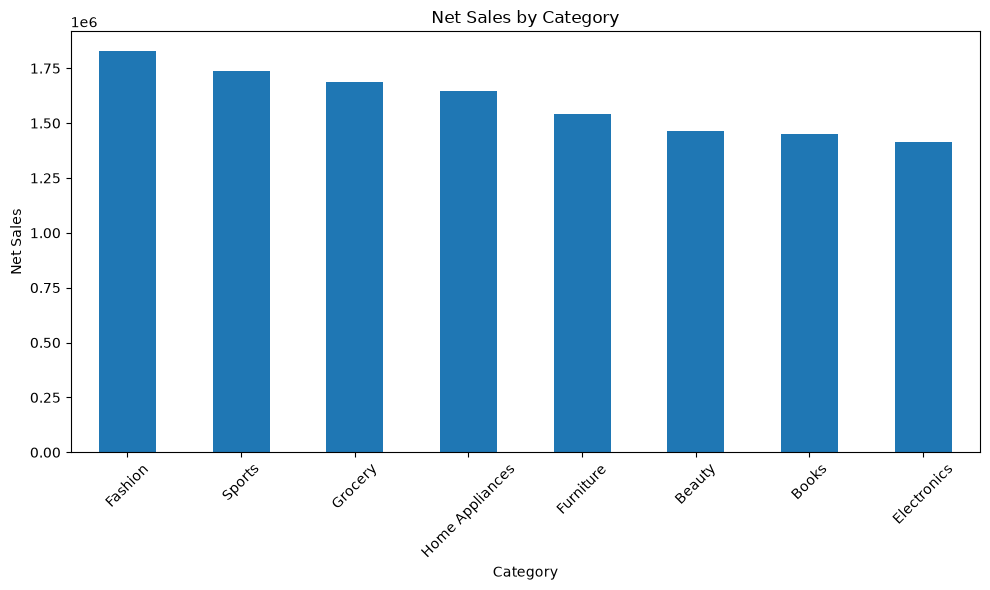

In [20]:
category_sales = df_clean.groupby("Category")["Net_Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_sales.plot(kind="bar")
plt.title("Net Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


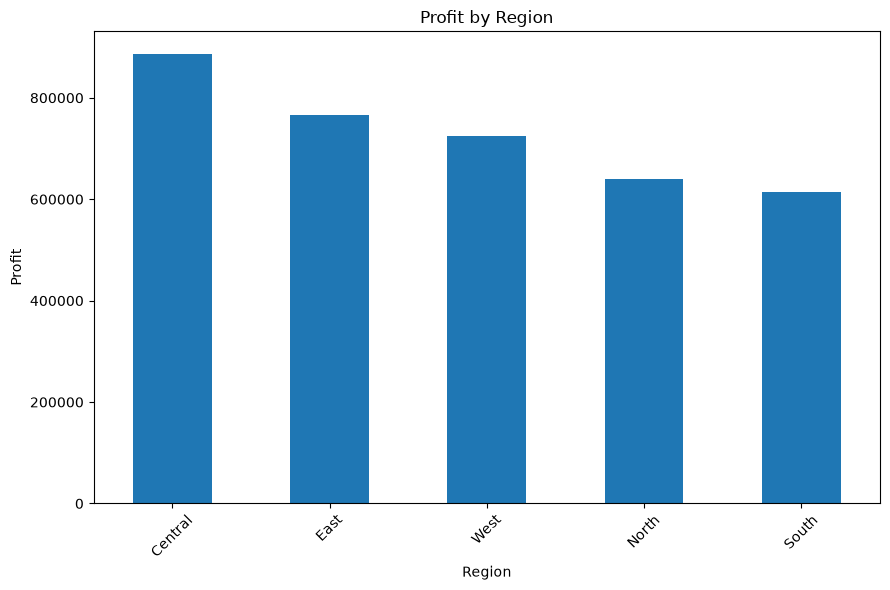

In [21]:
region_profit = df_clean.groupby("Region")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,6))
region_profit.plot(kind="bar")
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


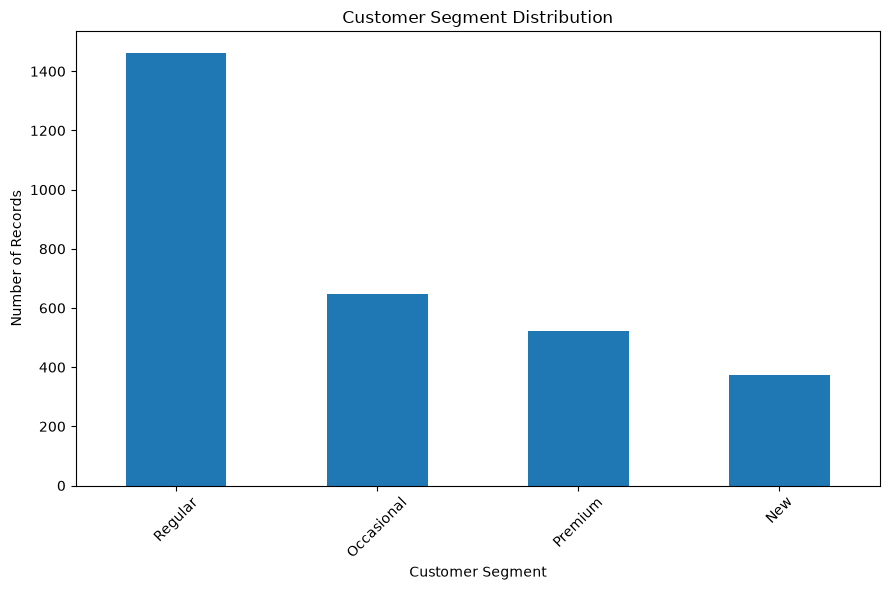

In [22]:
plt.figure(figsize=(9,6))
df_clean["Customer_Segment"].value_counts().plot(kind="bar")
plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Records")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


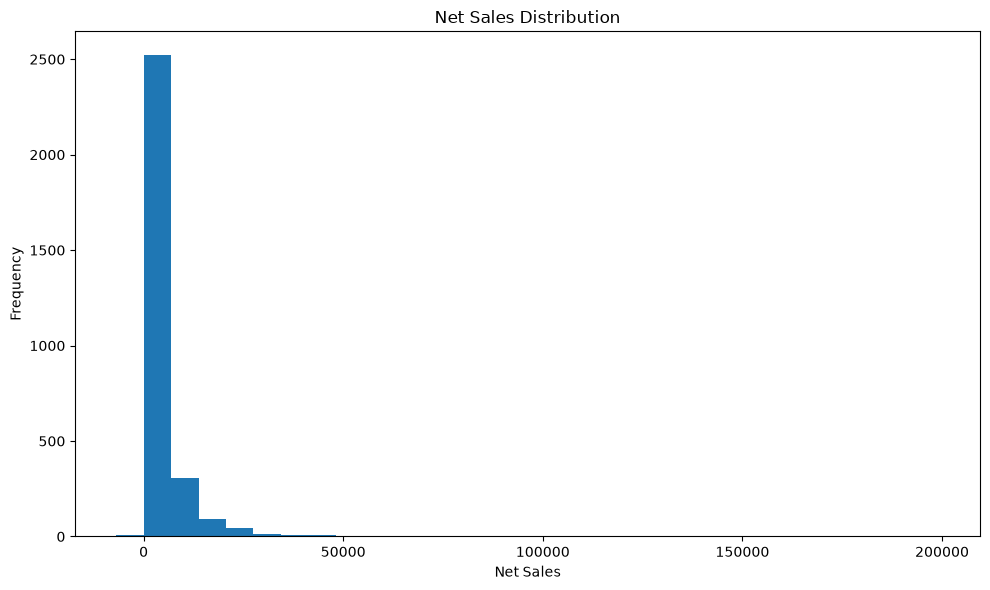

In [23]:
plt.figure(figsize=(10,6))
plt.hist(df_clean["Net_Sales"], bins=30)
plt.title("Net Sales Distribution")
plt.xlabel("Net Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


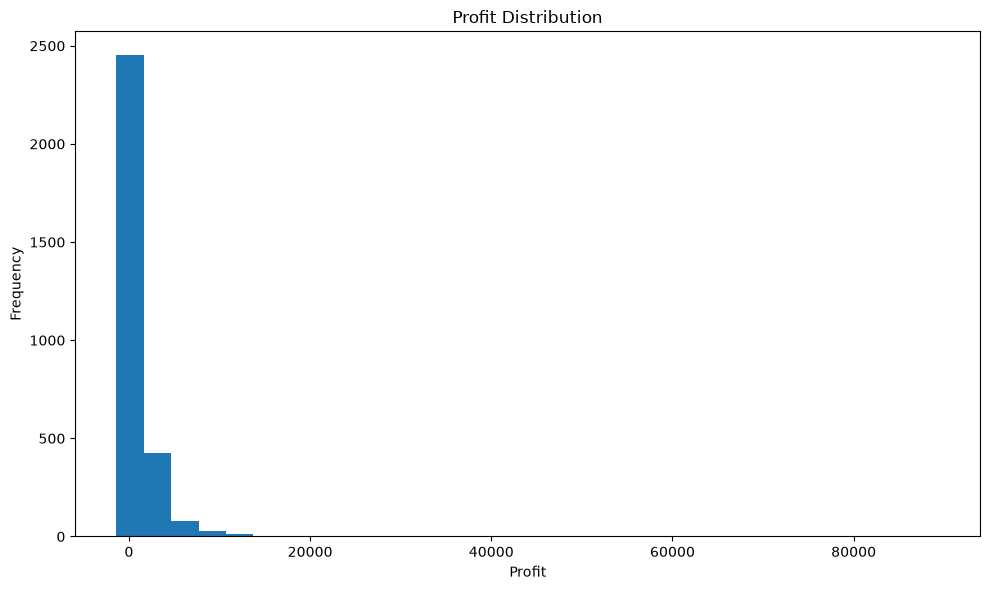

In [24]:
plt.figure(figsize=(10,6))
plt.hist(df_clean["Profit"], bins=30)
plt.title("Profit Distribution")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


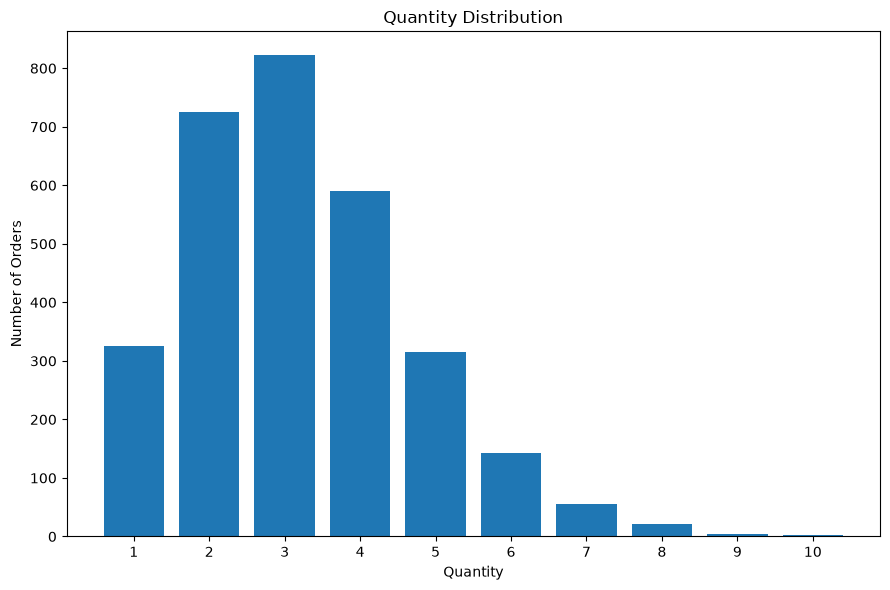

In [25]:
plt.figure(figsize=(9,6))
plt.hist(df_clean["Quantity"], bins=np.arange(0.5,11.5,1), rwidth=0.8)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Number of Orders")
plt.xticks(range(1,11))
plt.tight_layout()
plt.show()


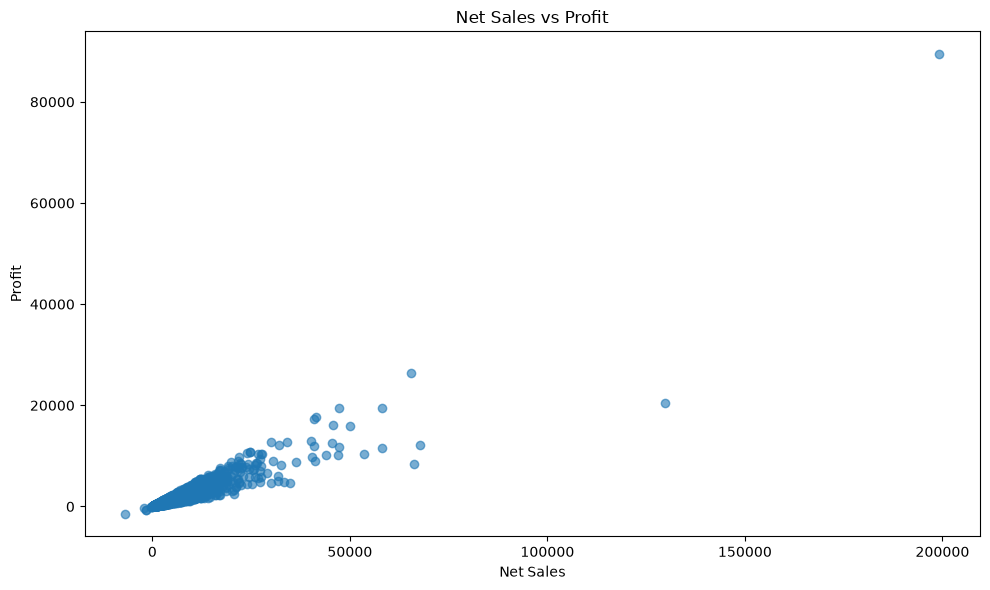

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(df_clean["Net_Sales"], df_clean["Profit"], alpha=0.6)
plt.title("Net Sales vs Profit")
plt.xlabel("Net Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()


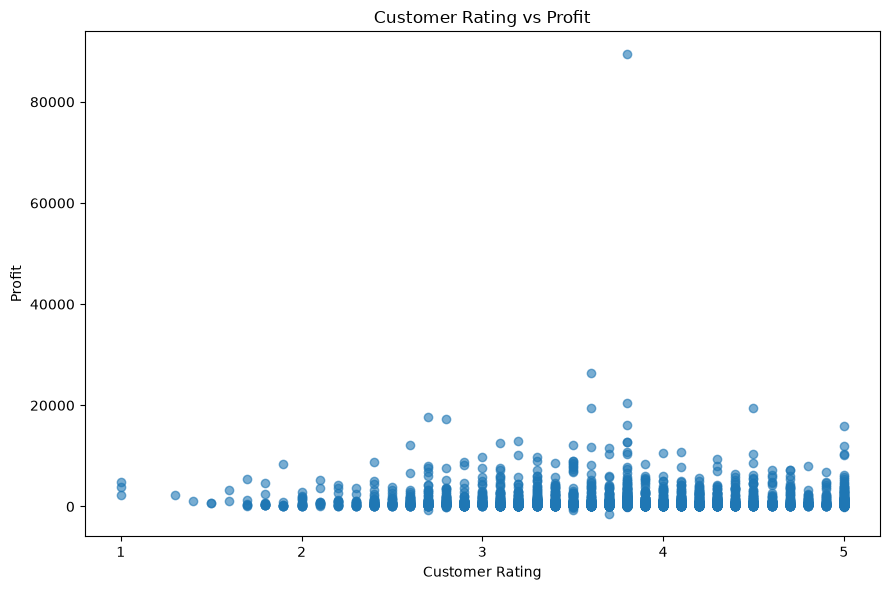

In [27]:
plt.figure(figsize=(9,6))
plt.scatter(df_clean["Customer_Rating"], df_clean["Profit"], alpha=0.6)
plt.title("Customer Rating vs Profit")
plt.xlabel("Customer Rating")
plt.ylabel("Profit")
plt.xticks([1,2,3,4,5])
plt.tight_layout()
plt.show()


## 13. Correlation Analysis

In [28]:
correlation = df_clean.select_dtypes(include=np.number).corr()
display(correlation)

print("Variables most correlated with Profit:")
display(correlation["Profit"].sort_values(ascending=False).head(10))


,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct,Year,Month
Customer_Age,1.000000,0.006162,-0.005412,-0.002894,-0.000060,-0.015912,-0.003952,0.031371,-0.003534,-0.009980,-0.005140,-0.008040,0.000987,-0.008933,0.003973,0.004149,0.003044,-0.011281,NaN,0.003571
Quantity,0.006162,1.000000,0.007678,0.013500,-0.002274,-0.004509,-0.011510,-0.001197,0.004189,-0.021917,0.001682,0.050710,0.259231,0.204904,0.261623,0.265247,0.225163,-0.003859,NaN,0.016123
Unit_Price,-0.005412,0.007678,1.000000,-0.010655,-0.024605,-0.008624,0.024070,-0.004227,0.004827,0.003881,-0.022813,-0.009520,0.870298,0.690998,0.817356,0.789187,0.786590,0.004359,NaN,0.002252
Discount_Pct,-0.002894,0.013500,-0.010655,1.000000,0.004373,0.025723,0.009361,-0.004992,0.008954,-0.008153,0.002304,0.003941,-0.010149,0.268106,-0.071118,-0.068179,-0.069607,-0.026137,NaN,0.011875
Shipping_Days,-0.000060,-0.002274,-0.024605,0.004373,1.000000,0.011631,0.021257,0.020269,-0.010660,0.002487,0.005604,0.018075,-0.024523,-0.028175,-0.025836,-0.022842,-0.029301,-0.034945,NaN,-0.011168
Customer_Rating,-0.015912,-0.004509,-0.008624,0.025723,0.011631,1.000000,0.015163,0.004724,-0.011952,-0.002016,0.010713,-0.002552,-0.008051,0.008875,-0.010378,-0.013356,-0.003024,0.006841,NaN,-0.016603
Delivery_Rating,-0.003952,-0.011510,0.024070,0.009361,0.021257,0.015163,1.000000,0.008966,0.001736,0.015583,-0.022665,-0.011318,0.012141,0.007628,0.013251,0.011636,0.015065,-0.024561,NaN,0.004480
Customer_Loyalty_Points,0.031371,-0.001197,-0.004227,-0.004992,0.020269,0.004724,0.008966,1.000000,0.049888,-0.005114,0.004721,-0.007355,-0.004581,-0.010530,-0.006323,-0.005645,-0.007124,0.003671,NaN,0.010346
Website_Session_Minutes,-0.003534,0.004189,0.004827,0.008954,-0.010660,-0.011952,0.001736,0.049888,1.000000,0.027914,0.002623,0.024706,0.002697,0.004305,0.004030,0.008093,-0.005126,-0.021589,NaN,-0.016081
Items_Viewed,-0.009980,-0.021917,0.003881,-0.008153,0.002487,-0.002016,0.015583,-0.005114,0.027914,1.000000,-0.018599,-0.015643,0.012257,0.029006,0.017412,0.012204,0.026440,-0.014491,NaN,-0.016395


Variables most correlated with Profit:


Profit               1.000000
Net_Sales            0.924392
Gross_Amount         0.890811
Estimated_Cost       0.840476
Unit_Price           0.786590
Discount_Amount      0.723374
Quantity             0.225163
Profit_Margin_Pct    0.172217
Items_Viewed         0.026440
Delivery_Rating      0.015065
Name: Profit, dtype: float64

## 14. Final Data-Quality Check

In [29]:
checks = {
    "Missing values": int(df_clean.isnull().sum().sum()),
    "Duplicate rows": int(df_clean.duplicated().sum()),
    "Invalid Quantity": int((~df_clean["Quantity"].between(1,10)).sum()),
    "Invalid Customer Age": int((~df_clean["Customer_Age"].between(18,100)).sum()),
    "Invalid Discount %": int((~df_clean["Discount_Pct"].between(0,100)).sum()),
    "Invalid Shipping Days": int((~df_clean["Shipping_Days"].between(1,14)).sum()),
    "Invalid Customer Rating": int((~df_clean["Customer_Rating"].between(1,5)).sum()),
    "Invalid Customer Satisfaction": int((~df_clean["Customer_Satisfaction"].between(1,5)).sum())
}

for name, value in checks.items():
    print(f"{name}: {value}")


Missing values: 0
Duplicate rows: 0
Invalid Quantity: 0
Invalid Customer Age: 0
Invalid Discount %: 0
Invalid Shipping Days: 0
Invalid Customer Rating: 0
Invalid Customer Satisfaction: 0


## 15. Export Cleaned Dataset

In [30]:
output_file = "cleaned_sales_dataset.csv"
df_clean.to_csv(output_file, index=False)

print("Cleaned dataset saved as:", output_file)
print("Final shape:", df_clean.shape)


Cleaned dataset saved as: cleaned_sales_dataset.csv
Final shape: (3005, 39)


## Conclusion
The notebook performs a full data-cleaning and exploratory-analysis workflow using NumPy, Pandas, and Matplotlib. It detects and fills missing values, removes duplicates, validates business rules such as Quantity, analyzes the data statistically, creates visualizations, and exports the cleaned dataset.
